# 06. Единая сетка и доменная диагностика

Все real и synthetic спектры переводятся на общую сетку 0–90° × 4096. После этого
проверяются synthetic/real и real/real различия на физически интерпретируемых признаках.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("неверный путь.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from project_paths import *
ensure_project_directories()

print("Project root:", PROJECT_ROOT)

Project root: D:\Users\user\Desktop\DS_XRD_project


In [ ]:
import subprocess

def run_script(script_name, *args):

    # Run one reproducible pipeline stage and stream its output.
    
    command = [sys.executable, str(PROJECT_ROOT / "src" / script_name), *map(str, args)]
    print("Running:", " ".join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

## Общая сетка, sqrt-нормировка и маска валидности

In [3]:
run_script("step5_preprocess_grid.py")
run_script("validate_stageB.py")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\step5_preprocess_grid.py
Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\validate_stageB.py


## Именованные физические признаки

In [4]:
run_script("step6_domain_features.py", "--workers", "16")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\step6_domain_features.py --workers 16


## Первый доменный классификатор

In [6]:
run_script("step6_domain_check.py")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\step6_domain_check.py


## Финальная wavelength-matched диагностика

In [7]:
run_script("domain_diag.py")
run_script("compare_iterations.py")

Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\domain_diag.py
Running: d:\Dev\envs\study\python.exe D:\Users\user\Desktop\DS_XRD_project\src\compare_iterations.py


## Галерея диагностических графиков

calibration_evolution.png


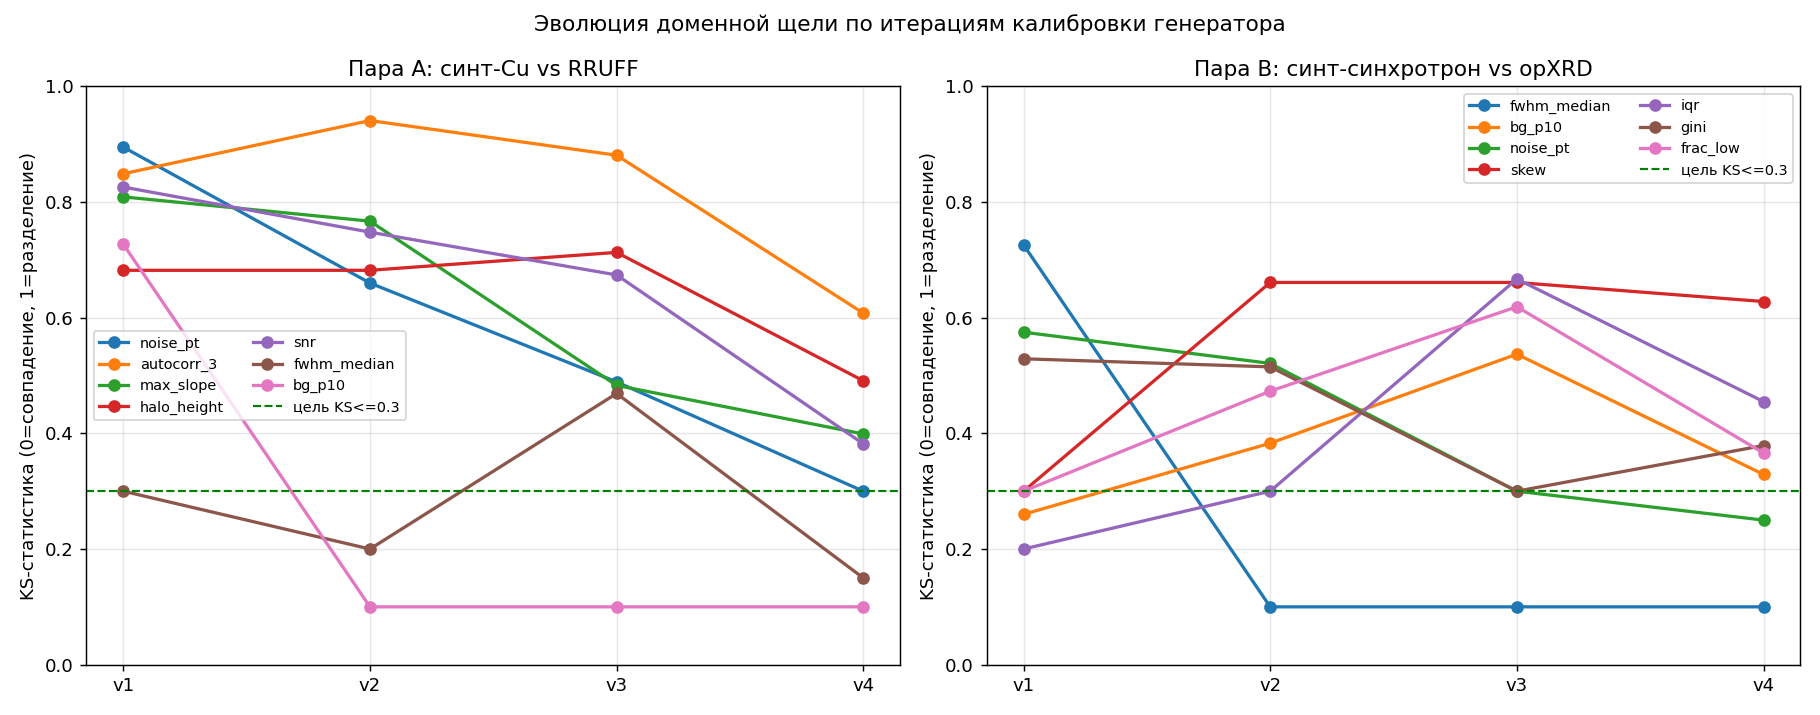

In [ ]:
from IPython.display import Image, display
domain_dir = OUTPUTS_DIR / "domain_diag"

for path in sorted(domain_dir.glob("*.png")):
    print(path.name)
    display(Image(filename=str(path)))

## Вывод

Корреляция физического движка с pymatgen подтверждает корректность отражений, однако
доменные классификаторы показывают, что лабораторные и синтетические профили, а также
RRUFF и opXRD, остаются различимыми.